In [1]:
#| default_exp detect


In [2]:
#|exports
from enum import Enum
from ultralytics import YOLO
from dataclasses import dataclass

from PIL import Image as PILImage, ImageDraw



# Step 4: Detect birds in a photo

![Step 4 diagram](https://raw.githubusercontent.com/jaewilson07/bird-watcher/main/docs/diagrams/04-step.png)

**Goal:** given a photo, tell me where the birds are.

We use a pre-trained object detector called YOLOv8n. It's small (~6MB), fast, and has 'bird' as one of its 80 classes.

Two functions live in `bird_watcher/find_birds.py`:

- `find_birds_in_image` — find every bird's bounding box
- `crop_bird_from_image` — cut out one bird for the species classifier

## Step 4.0 — Setup

In [3]:
from dotenv import load_dotenv
import os
assert load_dotenv(), "Failed to load .env file"

BIRD_MODEL = os.environ.get('BIRD_MODEL_QUALITY')
CONFIDENCE_THRESHOLD = 0.4

PHONE_IP = os.environ.get("PHONE_IP")
PHONE_URL = f"http://{PHONE_IP}:8080/photo.jpg"

HUGGINGFACE_API_KEY = os.environ.get("HUGGINGFACE_API_KEY", "")

OUTPUT_FOLDER = '../data/tests'

SAMPLE_IMAGE_PATH = '../data/samples/dog_bird.jpg'
# SAMPLE_IMAGE_PATH = '../data/samples/bird_plant.jpg'


The YOLO vision models have different types that balance speed for quality (higher quality object detection takes more time).

We can abstract (hide) having to remember each model variant, behind a simple lable 'QUALITY' or 'FAST'

an `Enum` stands for 'enumerator` which means "list out choices"

we use enumerators to abstract (hide) having to remember complicated strings 'yolo26n.pt' that don't actually mean anything to us, whereas 'QUALITY' and 'FAST' are obvious.



In [4]:
#| export

class YoloModelEnum(Enum):
    QUALITY = 'yolo26l.pt'
    FAST = 'yolo26n.pt'

In [5]:
print(f"this is the quality model: {YoloModelEnum.QUALITY.value}")
print(f"for the fast model: {YoloModelEnum.FAST.value}")

this is the quality model: yolo26l.pt
for the fast model: yolo26n.pt


Vision models are trained to identify specific objects (classes).

The gist of it is that you show the model 1000 images with labels, 100 images of golden retrievers, 100 images of doxins, 100 images of german shepherds, and that's how the model 'learns' to identify dog species.  

Same for birds (a different class)

We can tell the model what type of object to loook for if we know the index 

In [6]:
from ultralytics import YOLO

model = YOLO(YoloModelEnum.QUALITY.value) # will download the model if it doesn't exist

print(f"this model contains {len(model.names)} classes that we can apply detection on. including ...")

for idx, class_name in list(model.names.items()):
    if idx <=4:
        print(f"Class index: {idx}, Class name: {class_name}")

    bird_class_id = next((k for k, v in model.names.items() if v == 'bird'), None)

print(f"\n\nthe index for 'bird': {bird_class_id if bird_class_id is not None else 'not found'}")

this model contains 80 classes that we can apply detection on. including ...
Class index: 0, Class name: person
Class index: 1, Class name: bicycle
Class index: 2, Class name: car
Class index: 3, Class name: motorcycle
Class index: 4, Class name: airplane


the index for 'bird': 14


## 4.0 Basic Object Detection in images using a function

We can use the YOLO model to detect objects in an image.

The yolo model will identify multiple objects in the image, so we have to use a FOR loop to iterate over each object detected.

Typically object detection is described as a box that contains the object (the x and y boundaries describe where in the image the object is located -- top left corner, in the middle, bottom right).  the object detection will also describe the class of object found -- dog, cat bird

In [7]:

def detect_objects_in_image(img_path, confidence = .7, debug_prn=False) -> "Image.Image":
    from PIL import Image

    image = Image.open(img_path)
    results = model(str(img_path), conf=confidence, verbose=False) # detects objects in an image
        
    cropped_images  = []

    for result in results:
        if debug_prn:
            print(f"Detected {len(result.boxes)} objects in image: {img_path}")
        
        for detection in result.boxes:
            
            x_min, y_min, x_max, y_max =tuple(detection.xyxy[0].tolist())
            
            cropped_image = image.crop((x_min, y_min, x_max, y_max))
            
            cropped_images.append(cropped_image)
            

            if debug_prn:
                yolo_class_id=int(detection.cls[0]),
                yolo_class_name=model.names[int(detection.cls[0])]
                
                print(f"  {yolo_class_name} ({yolo_class_id}): ({int(x_min)}, {int(y_min)}) - ({int(x_max)}, {int(y_max)})")
        
    return cropped_images



Detecting objects in the sample image: ../data/samples/dog_bird.jpg with confidence threshold of 0.4


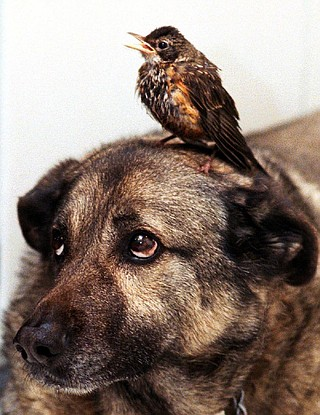

Detected 2 objects in image: ../data/samples/dog_bird.jpg
  bird ((14,)): (124, 25) - (266, 176)
  dog ((16,)): (0, 111) - (320, 414)


 there are 2 cropped images detected in the sample image: ../data/samples/dog_bird.jpg


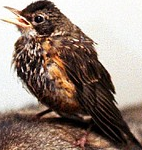

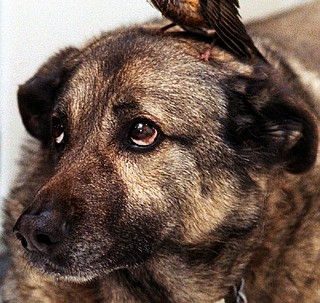

In [8]:
from IPython.display import display, Image

print(f"\n\nDetecting objects in the sample image: {SAMPLE_IMAGE_PATH} with confidence threshold of {CONFIDENCE_THRESHOLD}")

display(Image(filename=SAMPLE_IMAGE_PATH))

cropped_images = detect_objects_in_image(SAMPLE_IMAGE_PATH, confidence=CONFIDENCE_THRESHOLD, 
                                        debug_prn=True)


print(f"\n\n there are {len(cropped_images)} cropped images detected in the sample image: {SAMPLE_IMAGE_PATH}")
for img in cropped_images:
    display(img)

## Step 4.1 — Run YOLO and look at the raw output

While the ability to detect an object using a function is fun, if we have more complicated code it can mean we have A LOT of functions.  A better way of coding is to organize functions into classes.  

A class represents (describes) an entity or activity.

A 'jock' is a type of person, and when you hear 'jock' you have an idea of what that person is and some attributes that might describe it.  a jock will have properties like favorite_sport, bench_press, weight, top_speed and special functions like 'get_workout_routine' or 'execute_workout' that would be very different from the 'nerd' entity which would have different attributes and functions.

The same exists in gaming.  in gaming you have the 'tank' and the 'mage' archetype, but classes don't have to be people, you could have a house class (number of bedrooms, number of bathrooms, number of floors) or a vehicle class.

In coding, we use classes to model our world, and keep groups of functions together.

Let's rewrite the previous object detection function as a class.  

Why?  Right now, `detect_objects_in_image()` returns a list[Image] specifically the cropped images.  but what if i want to know the original xy coordinates of the box that we used to produce the cropped images.  or what if you wanted to know the class of the detection (dog and bird) our function can't do that.

What if we had a class ImageDetect that described all those properties (the original image, the detection box and the detection class) and included attached functions (methods)

In [ ]:
#| export

@dataclass
class ImageDetected:
    img_path: str
    detection_box : tuple[int, int, int, int]
    label_id: int # YOLO class index
    label: str # YOLO class name

    def __post_init__(self):
        pass

    
    @property
    def print_boundaries(self) -> None:
        x_min, y_min, x_max, y_max = self.detection_box
        return f"  {self.label} ({self.label_id}): ({int(x_min)}, {int(y_min)}) - ({int(x_max)}, {int(y_max)})"

    @property
    def print_cropped_image(self) -> "Image.Image":
        from PIL import Image
        image = Image.open(self.img_path)
        x_min, y_min, x_max, y_max = self.detection_box
        return image.crop((x_min, y_min, x_max, y_max))
    
    @property
    def print_cropped_bytes(self) -> bytes:
        from PIL import Image
        from io import BytesIO
        image = Image.open(self.img_path)
        x_min, y_min, x_max, y_max = self.detection_box
        cropped_image = image.crop((x_min, y_min, x_max, y_max))
        
        # Save the cropped image to a bytes buffer
        buffer = BytesIO()
        cropped_image.save(buffer, format="JPEG")
        return buffer.getvalue()

    
def detect_objects_in_image(img_path, model: YOLO, confidence: float = 0.7, debug_prn: bool = False) -> list[ImageDetected]:

    results = model(str(img_path), conf=confidence, verbose=False)

    detected_objects  = []

    for result in results:
        for detection in result.boxes:
            image_detect = ImageDetected(
                img_path=img_path,
                detection_box=tuple(detection.xyxy[0].tolist()),
                label_id=int(detection.cls[0]),
                label=model.names[int(detection.cls[0])]
            )
            detected_objects.append(image_detect)
            
            if debug_prn:
                image_detect.show_detection(debug_prn=True)
            
    return detected_objects


Our new code looks almost identical to the original function.  Except `detect_objects_in_images` now returns a list of `ImageDetect` class.

Why is that better?  Because now instead of just having a cropped image, we have all the original data including the bounding boxes, and class name in the `ImageDetect`

In the example below, what does 'show_detection' do?

Right now, we are just printing a 'bird' but what happens if we want to identify the type of bird (bluebird vs. robin), where should that function go?

detection on sample image ../data/samples/dog_bird.jpg using model: yolo26l.pt


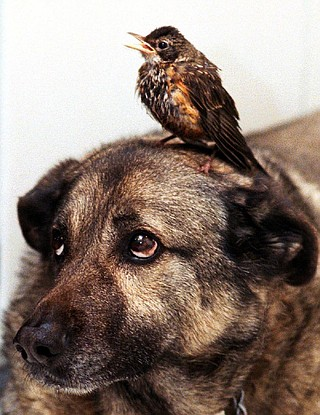

  bird (14): (124, 25) - (266, 176)


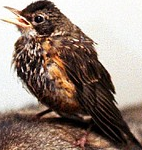

  dog (16): (0, 111) - (320, 414)


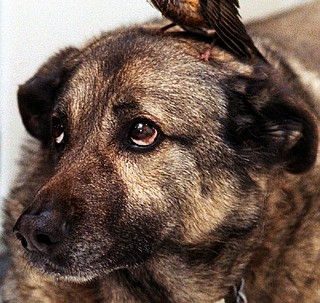

In [10]:
from IPython.display import Image, display


model = YOLO(YoloModelEnum.QUALITY.value)

print(f"detection on sample image {SAMPLE_IMAGE_PATH} using model: {YoloModelEnum.QUALITY.value}")
display(Image(filename = SAMPLE_IMAGE_PATH))

detected_objects = detect_objects_in_image(SAMPLE_IMAGE_PATH, model)

for obj in detected_objects:
    print(obj.print_boundaries)
    display(obj.print_cropped_image)    

## Step 4.6 — Draw the bounding boxes

Instead of cropping an image, we might want to draw lines around the original to show where the detected object was extracted from

In [11]:
#| export 


@dataclass
class ImageDetection:
    imag_path : str
    model : YOLO
    detections: list[ImageDetected] = None

    @property
    def image(self) -> PILImage.Image:
        
        return PILImage.open(self.imag_path).convert("RGB")

    
    @classmethod
    def from_path(cls, img_path: str,model: YOLO,  confidence: float = 0.7, debug_prn : bool = False) -> "ImageDetection":
        
        img =  cls(imag_path=img_path, model=model)

        img.get_detections(model=model, confidence=confidence, debug_prn=debug_prn)

        return img
    
    
    def get_detections(self, model: YOLO, confidence: float = 0.7, debug_prn: bool = False) -> list[ImageDetected]:
        
        self.detections = detect_objects_in_image(img_path = self.imag_path, model=model, confidence=confidence, debug_prn=debug_prn)
        
        return self.detections

    @property
    def print_detections(self) -> PILImage.Image:
        annotated = PILImage.open(self.imag_path).convert("RGB").copy()
        draw = ImageDraw.Draw(annotated)

        for detection in self.detections:
            x_min, y_min, x_max, y_max = detection.detection_box
            draw.rectangle([x_min, y_min, x_max, y_max], outline="red", width=2)
            draw.text((x_min, y_min), detection.label, fill="red")
        

        return annotated

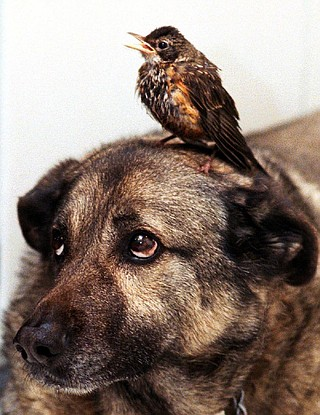

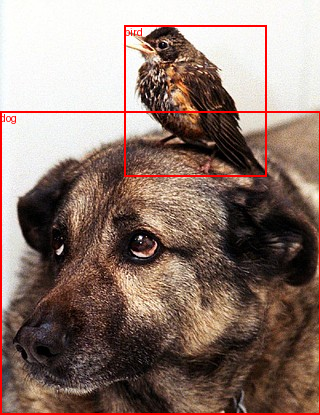

In [12]:

model = YOLO(YoloModelEnum.QUALITY.value)
sample = ImageDetection.from_path(img_path = SAMPLE_IMAGE_PATH, model=model, confidence=0.7, debug_prn=False)

display(sample.image)

display(sample.print_detections)

## What's next

**Step 5:** open [05-identify.ipynb](05-identify.ipynb) — we'll crop each bird and ask a different model "what species is this?"